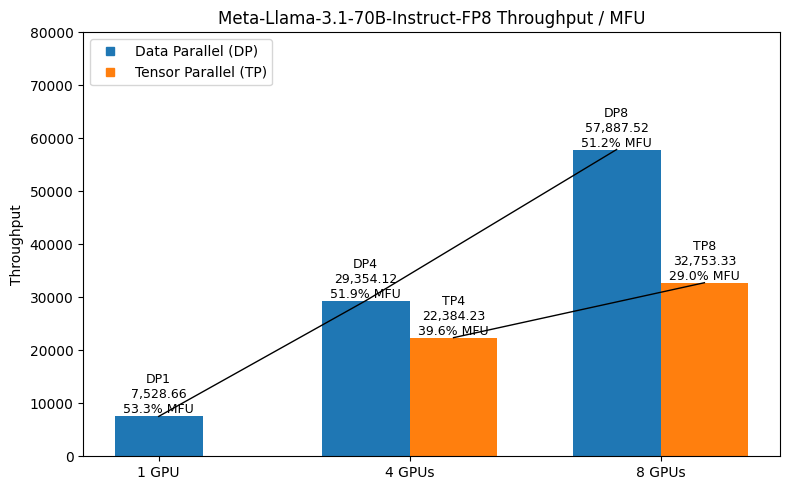

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Data
# GPU count, name, throughput, MFU
entries = [
    (1, "DP1",  7528.66, 53.3),
    (4, "DP4", 29354.12, 51.9),
    (4, "TP4", 22384.23, 39.6),
    (8, "DP8", 57887.52, 51.2),
    (8, "TP8", 32753.33, 29.0),
]

# NEW ORDER: 1 GPU (left), 4 GPUs (middle), 8 GPUs (right)
gpu_groups = [1, 4, 8]
x = np.arange(len(gpu_groups))  # [0, 1, 2]
bar_width = 0.35

# Figure out which strategies exist for each GPU count
strategies_by_gpu = defaultdict(list)
for gpu, name, thr, mfu in entries:
    if name.startswith("DP"):
        if "DP" not in strategies_by_gpu[gpu]:
            strategies_by_gpu[gpu].append("DP")
    elif name.startswith("TP"):
        if "TP" not in strategies_by_gpu[gpu]:
            strategies_by_gpu[gpu].append("TP")

# Use first two colors from the matplotlib color cycle for DP and TP
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
dp_color = color_cycle[0]
tp_color = color_cycle[1]

fig, ax = plt.subplots(figsize=(8, 5))

bar_positions = {}  # store x position and height for each bar

for gpu, name, thr, mfu in entries:
    group_idx = gpu_groups.index(gpu)
    strategies = strategies_by_gpu[gpu]

    if name.startswith("DP"):
        if "TP" in strategies:
            offset = -bar_width / 2
        else:
            offset = 0.0
        color = dp_color
    else:  # TP
        if "DP" in strategies:
            offset = bar_width / 2
        else:
            offset = 0.0
        color = tp_color

    x_pos = x[group_idx] + offset

    ax.bar(x_pos, thr, width=bar_width, color=color)
    bar_positions[name] = (x_pos, thr)

    label_text = f"{name}\n{thr:,.2f}\n{mfu:.1f}% MFU"
    ax.text(x_pos, thr, label_text, ha="center", va="bottom", fontsize=9)

# --- NEW LINES ---

# DP line: DP1 -> DP4 -> DP8
x_dp1, y_dp1 = bar_positions["DP1"]
x_dp4, y_dp4 = bar_positions["DP4"]
x_dp8, y_dp8 = bar_positions["DP8"]
ax.plot([x_dp1, x_dp4, x_dp8], [y_dp1, y_dp4, y_dp8],
        color="black", linewidth=1)

# TP line: TP4 -> TP8
x_tp4, y_tp4 = bar_positions["TP4"]
x_tp8, y_tp8 = bar_positions["TP8"]
ax.plot([x_tp4, x_tp8], [y_tp4, y_tp8],
        color="black", linewidth=1)

# -----------------

ax.set_xticks(x)
ax.set_xticklabels(["1 GPU", "4 GPUs", "8 GPUs"])
ax.set_ylabel("Throughput")
ax.set_title("Meta-Llama-3.1-70B-Instruct-FP8 Throughput / MFU")

dp_patch = plt.Line2D([0], [0], marker="s", linestyle="", color=dp_color, label="Data Parallel (DP)")
tp_patch = plt.Line2D([0], [0], marker="s", linestyle="", color=tp_color, label="Tensor Parallel (TP)")
ax.legend(handles=[dp_patch, tp_patch], loc="upper left")

ax.set_ylim(0, 80000)

plt.tight_layout()
plt.show()


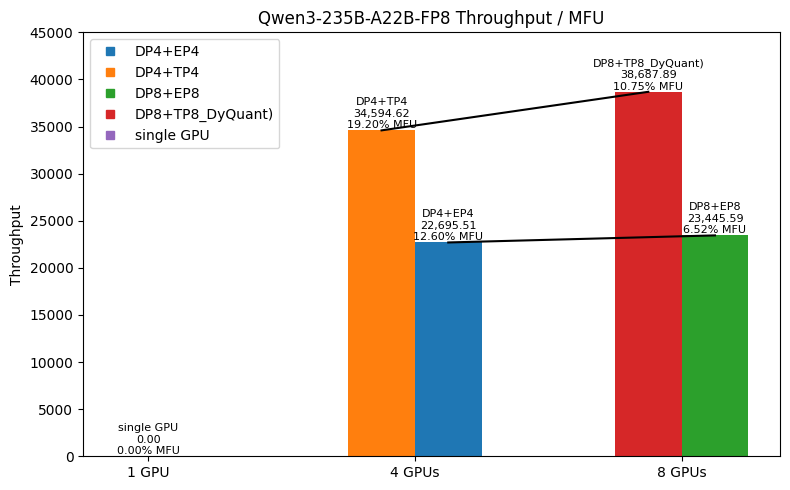

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_pipeline_strategies():
    # Data: (GPU count, name, throughput, MFU)
    entries = [
        (1, "single GPU",          0.0,      0.0),
        (4, "DP4+TP4",         34594.62,   19.2),
        (4, "DP4+EP4",         22695.51,   12.6),
        (8, "DP8+TP8_DyQuant)", 38687.89,  10.75),
        (8, "DP8+EP8",         23445.59,    6.52),
    ]

    # x-axis order: 1 GPU (left), 4 GPUs (middle), 8 GPUs (right)
    gpu_groups = [1, 4, 8]
    x = np.arange(len(gpu_groups))
    bar_width = 0.25

    # Which strategies exist at each GPU count?
    strategies_by_gpu = defaultdict(list)
    for gpu, name, thr, mfu in entries:
        if name not in strategies_by_gpu[gpu]:
            strategies_by_gpu[gpu].append(name)

    # Assign a color per strategy
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    strategy_names = sorted({name for _, name, _, _ in entries})
    strategy_color = {
        strategy_names[i]: color_cycle[i % len(color_cycle)]
        for i in range(len(strategy_names))
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_positions = {}  # (gpu, name) -> (x_pos, height)

    # Draw bars
    for gpu, name, thr, mfu in entries:
        group_idx = gpu_groups.index(gpu)
        strategies = strategies_by_gpu[gpu]
        idx_in_group = strategies.index(name)

        # center bars around the tick
        n = len(strategies)
        offset = (idx_in_group - (n - 1) / 2) * bar_width

        x_pos = x[group_idx] + offset
        color = strategy_color[name]

        ax.bar(x_pos, thr, width=bar_width, color=color)
        bar_positions[(gpu, name)] = (x_pos, thr)

        # Label: strategy, throughput, MFU
        label_text = f"{name}\n{thr:,.2f}\n{mfu:.2f}% MFU"
        ax.text(x_pos, thr, label_text, ha="center", va="bottom", fontsize=8)

    # ---- Lines ----
    # Line 1: DP4+TP4 -> DP8+TP8_DyQuant)
    x_dp4tp4, y_dp4tp4 = bar_positions[(4, "DP4+TP4")]
    x_dp8tp8, y_dp8tp8 = bar_positions[(8, "DP8+TP8_DyQuant)")]
    ax.plot([x_dp4tp4, x_dp8tp8],
            [y_dp4tp4, y_dp8tp8],
            color="black", linewidth=1.5, linestyle="-")

    # Line 2: DP4+EP4 -> DP8+EP8
    x_dp4ep4, y_dp4ep4 = bar_positions[(4, "DP4+EP4")]
    x_dp8ep8, y_dp8ep8 = bar_positions[(8, "DP8+EP8")]
    ax.plot([x_dp4ep4, x_dp8ep8],
            [y_dp4ep4, y_dp8ep8],
            color="black", linewidth=1.5, linestyle="-")
    # ----------------

    ax.set_xticks(x)
    ax.set_xticklabels(["1 GPU", "4 GPUs", "8 GPUs"])
    ax.set_ylabel("Throughput")
    ax.set_title("Qwen3-235B-A22B-FP8 Throughput / MFU")

    # Legend (bars)
    legend_handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", color=strategy_color[name], label=name)
        for name in strategy_names
    ]
    ax.legend(handles=legend_handles, loc="upper left")

    ax.set_ylim(0, 45000)  # adjust if you want more headroom

    plt.tight_layout()
    plt.show()

# Call it:
plot_pipeline_strategies()

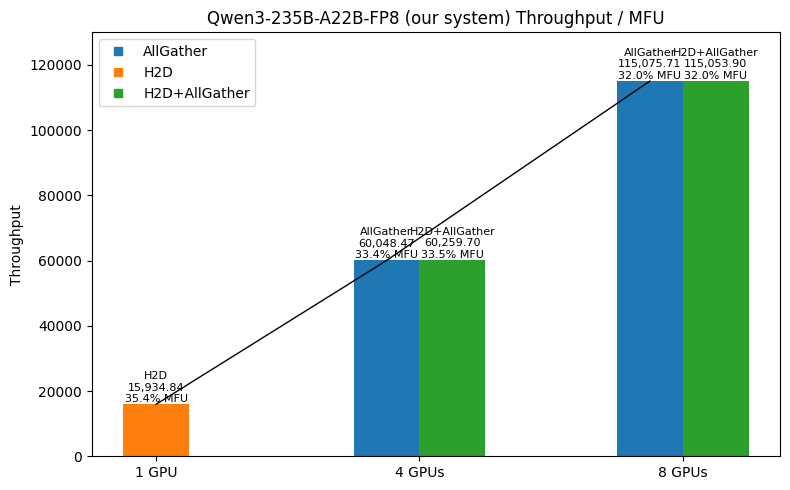

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_overlap_throughput():
    # Data: (GPU count, name, throughput, MFU)
    entries = [
        (1, "H2D",             15934.84, 35.4),
        (4, "AllGather",       60048.47, 33.4),
        (4, "H2D+AllGather",   60259.70, 33.5),
        (8, "AllGather",      115075.71, 32.0),
        (8, "H2D+AllGather",  115053.90, 32.0),
    ]

    # x-axis order: 1 GPU (left), 4 GPUs (middle), 8 GPUs (right)
    gpu_groups = [1, 4, 8]
    x = np.arange(len(gpu_groups))
    bar_width = 0.25

    # Which strategies exist at each GPU count?
    strategies_by_gpu = defaultdict(list)
    for gpu, name, thr, mfu in entries:
        if name not in strategies_by_gpu[gpu]:
            strategies_by_gpu[gpu].append(name)

    # Assign a color per strategy
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    strategy_names = sorted({name for _, name, _, _ in entries})
    strategy_color = {
        strategy_names[i]: color_cycle[i % len(color_cycle)]
        for i in range(len(strategy_names))
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    bar_positions = {}  # (gpu, name) -> (x_pos, height)

    for gpu, name, thr, mfu in entries:
        group_idx = gpu_groups.index(gpu)
        strategies = strategies_by_gpu[gpu]
        idx_in_group = strategies.index(name)

        # Center the group, spacing bars by bar_width
        n = len(strategies)
        # offsets like [-0.25, 0.25] for 2 bars, [-0.25, 0, 0.25] for 3, etc.
        offset = (idx_in_group - (n - 1) / 2) * bar_width

        x_pos = x[group_idx] + offset
        color = strategy_color[name]

        ax.bar(x_pos, thr, width=bar_width, color=color)
        bar_positions[(gpu, name)] = (x_pos, thr)

        # Text annotation
        label_text = f"{name}\n{thr:,.2f}\n{mfu:.1f}% MFU"
        ax.text(x_pos, thr, label_text, ha="center", va="bottom", fontsize=8)

    # ---- single line: H2D(1 GPU) -> AllGather(4 GPUs) -> AllGather(8 GPUs) ----
    x_h2d_1,  y_h2d_1  = bar_positions[(1, "H2D")]
    x_ag_4,   y_ag_4   = bar_positions[(4, "AllGather")]
    x_ag_8,   y_ag_8   = bar_positions[(8, "AllGather")]

    ax.plot([x_h2d_1, x_ag_4, x_ag_8],
            [y_h2d_1, y_ag_4, y_ag_8],
            color="black", linewidth=1)
    # --------------------------------------------------------------------------    

    ax.set_xticks(x)
    ax.set_xticklabels(["1 GPU", "4 GPUs", "8 GPUs"])
    ax.set_ylabel("Throughput")
    ax.set_title("Qwen3-235B-A22B-FP8 (our system) Throughput / MFU")

    # Legend from strategy colors
    legend_handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", color=strategy_color[name], label=name)
        for name in strategy_names
    ]
    ax.legend(handles=legend_handles, loc="upper left")

    # Adjust y-limit if needed
    ax.set_ylim(0, 130000)

    plt.tight_layout()
    plt.show()

# Call it:
plot_overlap_throughput()


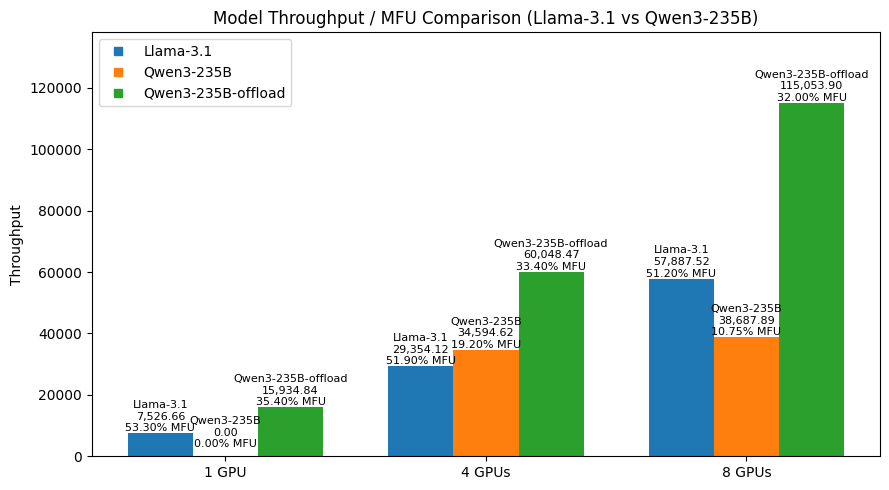

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_model_comparison():
    # Data: (GPU count, model, throughput, MFU)
    entries = [
        (1, "Llama-3.1",              7526.66, 53.3),
        (1, "Qwen3-235B",             0,       0),
        (1, "Qwen3-235B-offload",     15934.84, 35.4),
        (4, "Llama-3.1",              29354.12, 51.9),
        (4, "Qwen3-235B",             34594.62, 19.2),
        (4, "Qwen3-235B-offload",     60048.47, 33.4),
        (8, "Llama-3.1",              57887.52, 51.2),
        (8, "Qwen3-235B",             38687.89, 10.75),
        (8, "Qwen3-235B-offload",     115053.90, 32.0),
    ]

    gpu_groups = [1, 4, 8]                 # x-axis order
    x = np.arange(len(gpu_groups))
    bar_width = 0.25

    max_thr = max(thr for _, _, thr, _ in entries)

    # Which models appear at each GPU count?
    models_by_gpu = defaultdict(list)
    for gpu, model, thr, mfu in entries:
        if model not in models_by_gpu[gpu]:
            models_by_gpu[gpu].append(model)

    # Assign a color to each model
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    model_names = sorted({model for _, model, _, _ in entries})
    model_color = {
        model_names[i]: color_cycle[i % len(color_cycle)]
        for i in range(len(model_names))
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    bar_positions = {}  # (gpu, model) -> (x_pos, height)

    # Draw grouped bars
    for gpu, model, thr, mfu in entries:
        group_idx = gpu_groups.index(gpu)
        models = models_by_gpu[gpu]
        idx_in_group = models.index(model)
        n = len(models)

        # Symmetric offsets: e.g. for 3 bars -> [-0.25, 0, 0.25]
        offset = (idx_in_group - (n - 1) / 2) * bar_width
        x_pos = x[group_idx] + offset
        color = model_color[model]

        ax.bar(x_pos, thr, width=bar_width, color=color)
        bar_positions[(gpu, model)] = (x_pos, thr)

        # Text label (slightly above bar; handle throughput=0 nicely)
        label_y = thr if thr > 0 else max_thr * 0.02
        label_text = f"{model}\n{thr:,.2f}\n{mfu:.2f}% MFU"
        ax.text(x_pos, label_y, label_text, ha="center", va="bottom", fontsize=8)

    # Axes & title
    ax.set_xticks(x)
    ax.set_xticklabels(["1 GPU", "4 GPUs", "8 GPUs"])
    ax.set_ylabel("Throughput")
    ax.set_title("Model Throughput / MFU Comparison (Llama-3.1 vs Qwen3-235B)")

    # Legend
    legend_handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", color=model_color[model], label=model)
        for model in model_names
    ]
    ax.legend(handles=legend_handles, loc="upper left")

    # Y limit with some headroom
    ax.set_ylim(0, max_thr * 1.2)

    plt.tight_layout()
    plt.show()

# Call it:
plot_model_comparison()